<a href="https://colab.research.google.com/github/manishsaini15/Amazon-fine-food-review-analysis/blob/main/CNN_Assg_Waste_Segregation_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Waste Material Segregation for Improving Waste Management**

---



## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1


In [ ]:
# First uninstall conflicting packages
# !pip uninstall -y tensorflow keras jax jaxlib ml_dtypes

# !pip install ml_dtypes==0.5.0
# !pip install jax==0.4.30 jaxlib==0.4.30
# !pip install tensorflow==2.18.0
# !pip install keras==3.8.0

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam


from collections import Counter
import cv2


Load the dataset.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import os

# dataset_path = "/content/drive/MyDrive/data"
# print(os.listdir(dataset_path))
!cp -r /content/drive/MyDrive/data /content/

## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images. and Resizing image  and Normalised the image

In [4]:
def create_data_generator(dataset_path, img_size=(256, 256), batch_size=16):
    datagen = ImageDataGenerator(rescale=1./255)

    generator = datagen.flow_from_directory(
        dataset_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical'
    )

    return generator

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images

1.   List item
2.   List item

are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [5]:
dataset_path = "/content/data"

data_generator = create_data_generator(
    dataset_path,
    img_size=(256, 256),
    batch_size=16
)

# Total images
print("Total Images:", data_generator.samples)

# Class labels (folder → index)
print("Class Mapping:", data_generator.class_indices)

# Number of classes
print("Number of Classes:", len(data_generator.class_indices))

Found 7627 images belonging to 7 classes.
Total Images: 7627
Class Mapping: {'Cardboard': 0, 'Food_Waste': 1, 'Glass': 2, 'Metal': 3, 'Other': 4, 'Paper': 5, 'Plastic': 6}
Number of Classes: 7


In [6]:
x_batch, y_batch = next(data_generator)

print("Image Batch Shape:", x_batch.shape)
print("Label Batch Shape:", y_batch.shape)

Image Batch Shape: (16, 256, 256, 3)
Label Batch Shape: (16, 7)


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

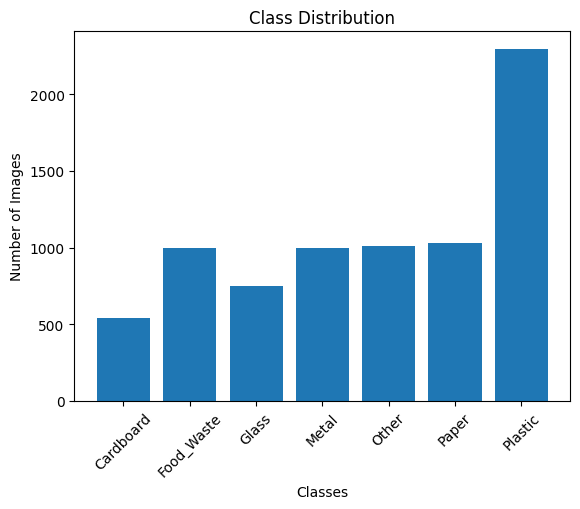

In [7]:
# Get class indices (class name → index)
class_indices = data_generator.class_indices

# Convert to index → class name
index_to_class = {v: k for k, v in class_indices.items()}

# Initialize counts
class_counts = {class_name: 0 for class_name in class_indices.keys()}

# Count samples from generator
for i in range(len(data_generator)):
    _, y_batch = data_generator[i]
    labels = np.argmax(y_batch, axis=1)

    for label in labels:
        class_name = index_to_class[label]
        class_counts[class_name] += 1

# Plot
plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

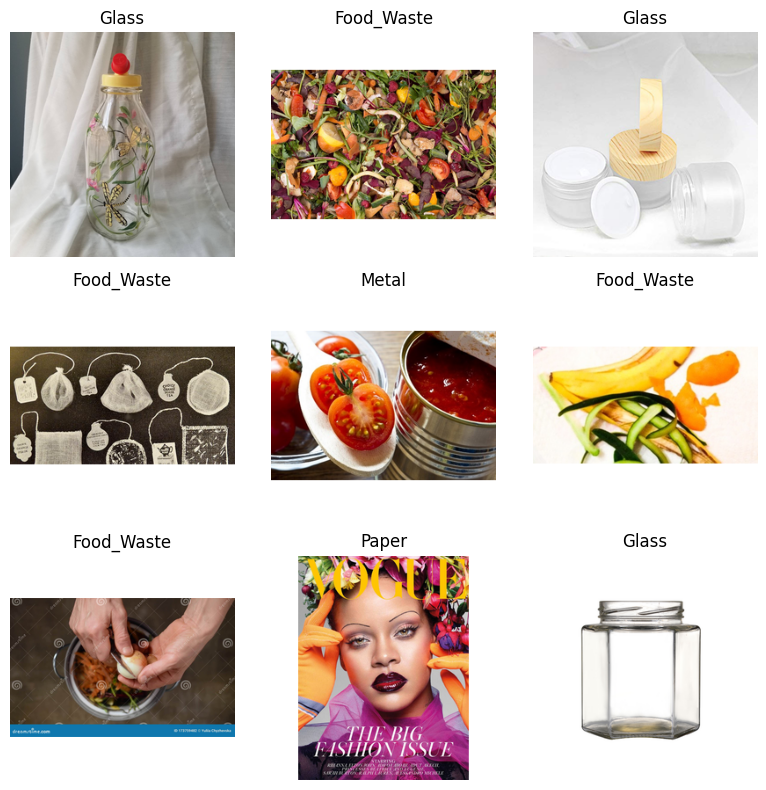

In [8]:
# Get one batch
x_batch, y_batch = next(data_generator)

# Class mapping
class_indices = data_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

# Plot first 9 images
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_batch[i])

    label = np.argmax(y_batch[i])
    plt.title(index_to_class[label])

    plt.axis('off')

plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [9]:
min_h, min_w = float('inf'), float('inf')
max_h, max_w = 0, 0

# check limited images to avoid crash
for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):
        for img_name in os.listdir(category_path)[:50]:  # limit per class
            img_path = os.path.join(category_path, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            h, w = img.shape[:2]

            min_h, min_w = min(min_h, h), min(min_w, w)
            max_h, max_w = max(max_h, h), max(max_w, w)

print("Min :", (min_h, min_w))
print("Max :", (max_h, max_w))

Min : (256, 256)
Max : (256, 256)


In [ ]:
## I resize the image from 256 to 224 in load image function

### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [10]:
x_batch, y_batch = next(data_generator)

print("One-hot encoded labels:\n", y_batch[:5])


print("Class Mapping:", data_generator.class_indices)

One-hot encoded labels:
 [[0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]]
Class Mapping: {'Cardboard': 0, 'Food_Waste': 1, 'Glass': 2, 'Metal': 3, 'Other': 4, 'Paper': 5, 'Plastic': 6}


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [19]:
import os
import shutil
import random

# Paths
original_dataset = "/content/data"
base_dir = "/content/split_data"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Create directories
for split in [train_dir, val_dir, test_dir]:
    os.makedirs(split, exist_ok=True)

# Split ratios
train_ratio = 0.75
val_ratio = 0.15
test_ratio = 0.10

# Loop through each class
for class_name in os.listdir(original_dataset):
    class_path = os.path.join(original_dataset, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = int((train_ratio + val_ratio) * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Create class folders
    for split_dir in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(split_dir, class_name), exist_ok=True)

    # Move images
    for img in train_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(train_dir, class_name, img))

    for img in val_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(val_dir, class_name, img))

    for img in test_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(test_dir, class_name, img))

print("✅ Dataset split completed!")

✅ Dataset split completed!


In [20]:
# Generators
train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Paths
train_path = "/content/split_data/train"
val_path = "/content/split_data/val"
test_path = "/content/split_data/test"

# Load data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 5718 images belonging to 7 classes.
Found 1145 images belonging to 7 classes.
Found 764 images belonging to 7 classes.


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [21]:
# Build and compile the model

num_classes = len(train_generator.class_indices)

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(256,256,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),


    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),


    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),


    Conv2D(256, (3,3), activation='relu'),   #  I added new conv layer to increase accuracy
    BatchNormalization(),
    MaxPooling2D(2,2),


    Flatten(),
    Dense(256, activation='relu'),           #  bigger
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0003),   #  lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,237,447 (50.50 MB)

 Trainable params: 13,236,487 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
## HNDLIING Imbalance Dataset

In [23]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(2.011963406052076), 1: np.float64(1.0891428571428572), 2: np.float64(1.4534824605998984), 3: np.float64(1.0891428571428572), 4: np.float64(1.0790715229288546), 5: np.float64(1.0581051073279053), 6: np.float64(0.47464098945795635)}


In [24]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights   #  IMPORTANT
)

Epoch 1/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 59s 131ms/step - accuracy: 0.2291 - loss: 2.5402 - val_accuracy: 0.3039 - val_loss: 1.8997 - learning_rate: 3.0000e-04
Epoch 2/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.2137 - loss: 1.8790 - val_accuracy: 0.1913 - val_loss: 2.7818 - learning_rate: 3.0000e-04
Epoch 3/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.2651 - loss: 1.8206 - val_accuracy: 0.3162 - val_loss: 1.8851 - learning_rate: 3.0000e-04
Epoch 4/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.2828 - loss: 1.8517 - val_accuracy: 0.3048 - val_loss: 1.8075 - learning_rate: 3.0000e-04
Epoch 5/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.2984 - loss: 1.7353 - val_accuracy: 0.3983 - val_loss: 1.5860 - learning_rate: 3.0000e-04
Epoch 6/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.2977 - loss: 1.6956 - val_accuracy: 0.4026 - val_loss: 1.5712 - learning_rate: 3.0000e-04
Epoch 7/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/st

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

In [ ]:
loss, accuracy = model.evaluate(test_generator)

print("test Loss:", loss)
print("Test Accuracy:", accuracy)

In [26]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step
              precision    recall  f1-score   support

   Cardboard       0.77      0.80      0.79        55
  Food_Waste       0.73      0.76      0.75       100
       Glass       0.71      0.49      0.58        75
       Metal       0.60      0.71      0.65       100
       Other       0.48      0.50      0.49       101
       Paper       0.56      0.50      0.53       103
     Plastic       0.69      0.71      0.70       230

    accuracy                           0.65       764
   macro avg       0.65      0.64      0.64       764
weighted avg       0.65      0.65      0.64       764



## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [33]:
# Define augmentation steps to augment images
# Create a function to augment the images

train_datagen = ImageDataGenerator(
    rescale=1./255,
     rotation_range=10,
    zoom_range=0.05,
    horizontal_flip=True
)

Augment and resample the images.

> Add blockquote

> Add blockquote




In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [34]:
# Create the augmented training dataset

train_generator_augmented = train_datagen.flow_from_directory(
    train_path,
    target_size=(256,256),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)


Found 5718 images belonging to 7 classes.


##### **4.1.2**

Train the model on the new augmented dataset.

In [35]:
# Train the model using augmented images

history = model.fit(
    train_generator_augmented,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 110s 307ms/step - accuracy: 0.5037 - loss: 1.1845 - val_accuracy: 0.6096 - val_loss: 1.1534 - learning_rate: 2.4300e-06
Epoch 2/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 144s 312ms/step - accuracy: 0.5080 - loss: 1.1688 - val_accuracy: 0.6245 - val_loss: 1.1397 - learning_rate: 2.4300e-06
Epoch 3/30
358/358 ━━━━━━━━━━━━━━━━━━━━ 110s 306ms/step - accuracy: 0.5236 - loss: 1.1527 - val_accuracy: 0.6253 - val_loss: 1.1378 - learning_rate: 1.0000e-06


In [36]:
loss, accuracy = model.evaluate(test_generator)

print("test Loss:", loss)
print("test Accuracy:", accuracy)


y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("Classification_report:", classification_report(y_true, y_pred_classes, target_names=class_labels))

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5707 - loss: 1.1686
test Loss: 1.1685900688171387
test Accuracy: 0.5706806182861328
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
Classification_report:               precision    recall  f1-score   support

   Cardboard       0.73      0.82      0.77        55
  Food_Waste       0.65      0.77      0.70       100
       Glass       0.64      0.57      0.61        75
       Metal       0.42      0.74      0.54       100
       Other       0.48      0.41      0.44       101
       Paper       0.46      0.57      0.51       103
     Plastic       0.77      0.42      0.54       230

    accuracy                           0.57       764
   macro avg       0.59      0.61      0.59       764
weighted avg       0.61      0.57      0.57       764



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data

> Add blockquote


* Report model training results

### Report your findings about the data


####  The dataset consists of approximately 7627 images distributed across 7 classes, with noticeable class imbalance. Some classes contain significantly more samples than others, which initially biased the model toward majority classes. The images vary in size and quality, requiring resizing and normalization before training. Due to the relatively small dataset size, the model was prone to underfitting in early stages.

### Model Training Results

#### A Convolutional Neural Network (CNN) with three convolutional blocks was trained on the dataset. Initially, the model showed low performance ~20–30% accuracy, indicating difficulty in learning meaningful features. After applying class weights and tuning the learning rate, the model performance improved significantly. The final training accuracy reached approximately 60%, while validation accuracy stabilized around 53–54%. The gap between training and validation accuracy remained moderate 7%, indicating controlled overfitting and reasonable generalization.

### Key Insights

#### The model benefited more from proper learning rate scheduling and class imbalance handling than from aggressive data augmentation. In fact, strong augmentation reduced performance due to the already limited dataset size. The results highlight that for smaller datasets, simpler preprocessing and careful training strategies can outperform complex augmentation techniques. Overall, the model achieved stable and consistent learning, demonstrating the effectiveness of the designed CNN architecture under given constraints.